In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','no-latex', 'notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [4]:
def compute_IG(imbalances):
    return (imbalances[:,:,0] - np.min(imbalances, axis=-1)) / imbalances[:,:,0]

### Lorenz 96, IG vs k both with and without embeddings

In [34]:
epsilons = np.linspace(0.,1.5,31)
taus = np.array([1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 50, 70, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500])
alphas = np.linspace(0.,0.25,50)

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((len(taus),len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(taus),len(epsilons),len(alphas)))
for i_tau, tau in enumerate(taus):
    info_imbalances_X_to_Y[i_tau], info_imbalances_Y_to_X[i_tau] = pickle.load(open(f"./analysis/ig_allcoords/pickles/lorenz96/tau{tau}.p","rb"))
IGs_X_to_Y = compute_IG(info_imbalances_X_to_Y)
IGs_Y_to_X = compute_IG(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((len(taus),len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((len(taus),len(epsilons),len(alphas))) 
for i_tau, tau in enumerate(taus):
    info_imbalances_X_to_Y_emb[i_tau], info_imbalances_Y_to_X_emb[i_tau] = pickle.load(open(f"./analysis/ig_embeddings/pickles/lorenz96/tau{tau}.p","rb"))
IGs_X_to_Y_emb = compute_IG(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb = compute_IG(info_imbalances_Y_to_X_emb)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


epsilon = 0.75


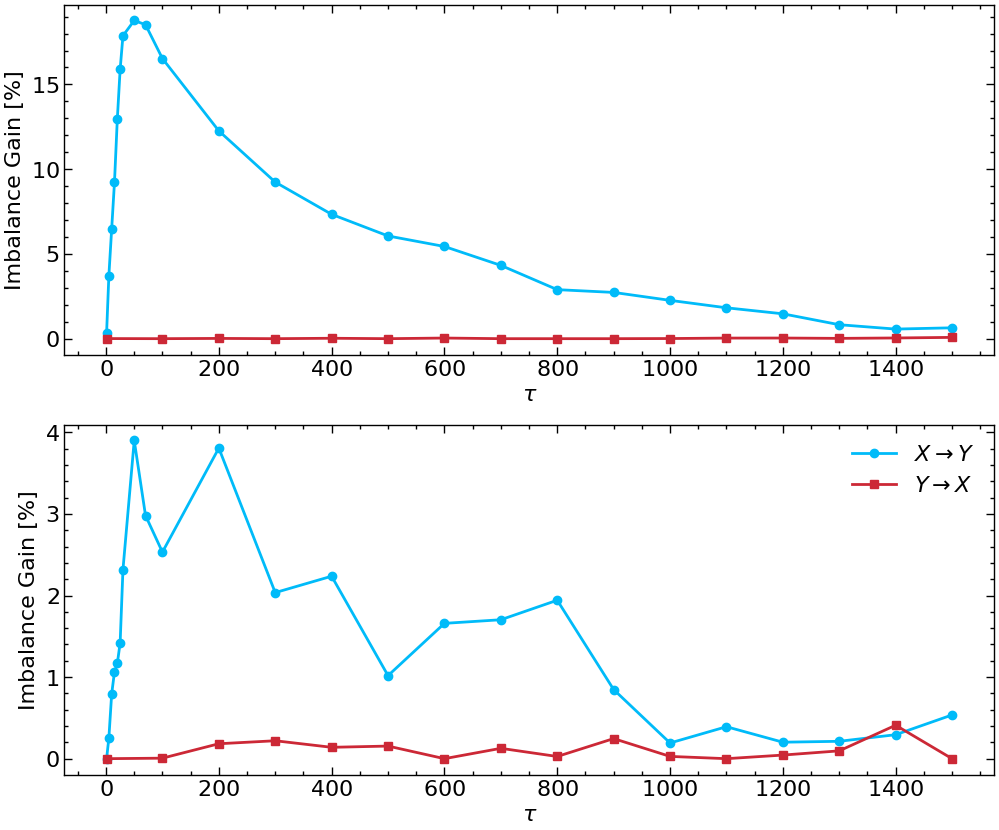

In [35]:
i_eps = 15
print(f"epsilon = {epsilons[i_eps]}")
samples_xtoy = np.append([0],np.arange(4,len(taus)))
samples_ytox = np.append([0],np.arange(12,len(taus)))

plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(12,10))

ax[0].plot(taus[samples_xtoy], 100*IGs_X_to_Y[samples_xtoy,i_eps], 'o-', color=colors[0])
ax[0].plot(taus[samples_ytox], 100*IGs_Y_to_X[samples_ytox,i_eps], 's-', color=colors[1])
ax[1].plot(taus[samples_xtoy], 100*IGs_X_to_Y_emb[samples_xtoy,i_eps], 'o-', color=colors[0], label=f"$X\\rightarrow Y$")
ax[1].plot(taus[samples_ytox], 100*IGs_Y_to_X_emb[samples_ytox,i_eps], 's-', color=colors[1], label=f"$Y\\rightarrow X$")

ax[0].set(ylabel="Imbalance Gain [%]", xlabel="$\\tau$")
ax[1].set(ylabel="Imbalance Gain [%]", xlabel="$\\tau$")
ax[0].legend()
ax[1].legend()

#plt.savefig("./figures/lorenz96_vs_tau_all_and_emb.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

epsilon = 1.0


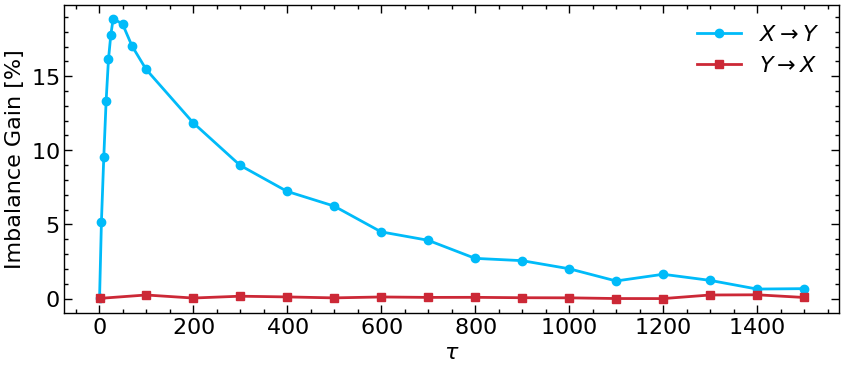

In [42]:
i_eps = 20
print(f"epsilon = {epsilons[i_eps]}")
samples_xtoy = np.append([0],np.arange(4,len(taus)))
samples_ytox = np.append([0],np.arange(12,len(taus)))

plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(taus[samples_xtoy], 100*IGs_X_to_Y[samples_xtoy,i_eps], 'o-', color=colors[0], label=f"$X\\rightarrow Y$")
ax.plot(taus[samples_ytox], 100*IGs_Y_to_X[samples_ytox,i_eps], 's-', color=colors[1], label=f"$Y\\rightarrow X$")

ax.set(ylabel="Imbalance Gain [%]", xlabel="$\\tau$")
ax.legend()

#plt.savefig("./figures/lorenz96_vs_tau.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()